In [5]:
import numpy as np
import cv2
from sim import DefaultOddElasticitySim, TrainedPolicySim
from PIL import Image

C:\Users\PUBLIC_USER\CloudStorage\Desktop\final project\job\RLMetamaterialLocomotion-main\RLMetamaterialLocomotion-main\.venv\Lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


pygame 2.6.1 (SDL 2.28.4, Python 3.11.9)
Hello from the pygame community. https://www.pygame.org/contribute.html


In [6]:
def stacked_frames(sim, start, gap, n, xrange, yrange):
    width = xrange[1] - xrange[0]
    height = yrange[1] - yrange[0]
    stacked = np.zeros((height*n, width, 3), dtype='uint8')
    sim.reset_seed()
    sim.steps(start)
    for i in range(n):
        frame = sim.render_rainbow()
        stacked[i*height:(i+1)*height,:,:] = frame[yrange[0]:yrange[1], xrange[0]:xrange[1], :]
        sim.steps(gap)
    return stacked

In [1]:
sim_crawler_indep = TrainedPolicySim("results/1686/checkpoint_1000.pt", num_envs=1)
sim_crawler_nr = DefaultOddElasticitySim("crawler", 10, num_envs=1)
sim_ring_indep = TrainedPolicySim("results/1748/checkpoint_1000.pt", num_envs=1)
sim_ring_nr = DefaultOddElasticitySim("ring", 10, num_envs=1)

NameError: name 'TrainedPolicySim' is not defined

In [73]:
def sims_side_by_side(sims, titles, start, gap, n, xrange, yrange):
    text_pad = 30
    width = xrange[1] - xrange[0]
    height = yrange[1] - yrange[0]
    stacked = np.zeros((height*n+text_pad, width*len(sims), 3), dtype='uint8')
    for i in range(len(sims)):
        stacked[text_pad:,width*i:width*(i+1),:] = stacked_frames(sims[i], start, gap, n, xrange, yrange)
        font, font_scale, thickness = cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1
        text_width, text_height = cv2.getTextSize(titles[i], font, font_scale, thickness)[0]
        stacked = cv2.putText(stacked, titles[i], (int(width*(i+0.5) - text_width/2), text_pad//2 + text_height//2), font, 
                   font_scale, (255, 255, 255), thickness, cv2.LINE_AA)
    return stacked
    

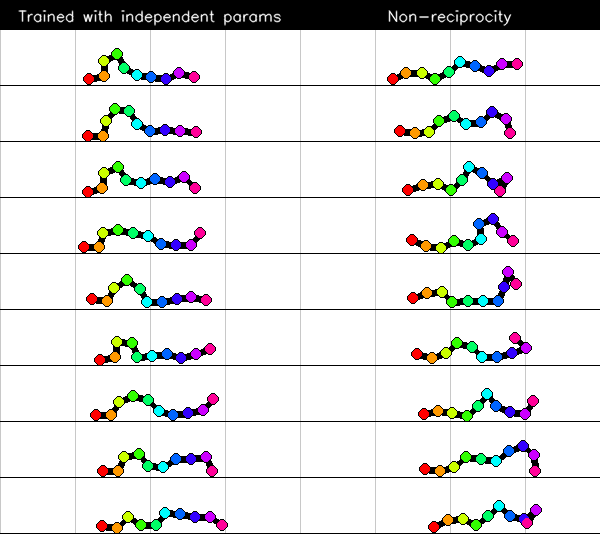

In [74]:
i = Image.fromarray(sims_side_by_side([sim_crawler_indep, sim_crawler_nr], ["Trained with independent params", "Non-reciprocity"], 100, 10, 9, [0,300],[180,236]))
i.save("final_plots/crawler_indep_frames.png")
i

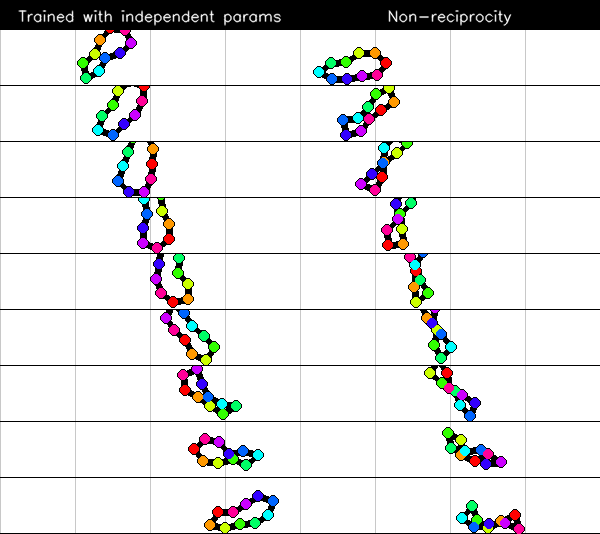

In [75]:
i = Image.fromarray(sims_side_by_side([sim_ring_indep, sim_ring_nr], ["Trained with independent params", "Non-reciprocity"], 220, 10, 9, [300,600],[180,236]))
i.save("final_plots/ring_indep_frames.png")
i

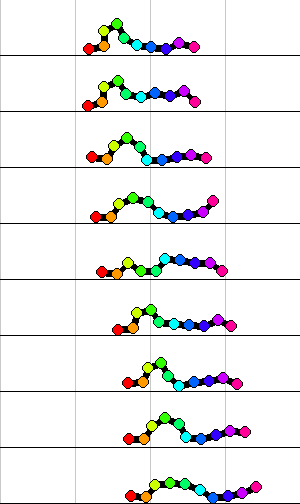

In [11]:
i = Image.fromarray(stacked_frames(sim, 100, 20, 9, [0,300],[180,236]))
# i.save("final_plots/crawler_rolling_frames.png")
i